# Check processed 2D labels

Enter a 3D BraTS case id, then display every saved 2D label slice under `outputs_task1/processed_slices`. Each `.npz` stores `label` with shape `[3, H, W]`, where the channels are `WT`, `TC`, and `ET`.

In [16]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

DATA_ROOT = Path(r"D:\Classes\AIformedical\LAB2\Lab2\outputs_task1\processed_slices")
if not DATA_ROOT.exists():
    DATA_ROOT = Path.cwd() / "outputs_task1" / "processed_slices"

LABEL_NAMES = ("WT", "TC", "ET")
LABEL_COLORS = {
    "WT": (0.00, 0.62, 0.90),
    "TC": (1.00, 0.62, 0.10),
    "ET": (0.95, 0.15, 0.18),
}
LABEL_CMAPS = {
    name: ListedColormap([(0.0, 0.0, 0.0, 1.0), (*color, 1.0)])
    for name, color in LABEL_COLORS.items()
}

print(f"Data root: {DATA_ROOT}")

Data root: D:\Classes\AIformedical\LAB2\Lab2\outputs_task1\processed_slices


In [17]:
_SLICE_RE = re.compile(r"_slice_(\d+)\.npz$", re.IGNORECASE)


def list_case_ids(data_root=DATA_ROOT):
    root = Path(data_root)
    if not root.exists():
        raise FileNotFoundError(f"processed_slices directory not found: {root}")
    return sorted(path.name for path in root.iterdir() if path.is_dir())


def resolve_case_id(case_id, data_root=DATA_ROOT):
    raw = str(case_id).strip()
    if not raw:
        raise ValueError("case_id is empty")

    cases = list_case_ids(data_root)
    if raw in cases:
        return raw

    lower_to_case = {case.lower(): case for case in cases}
    if raw.lower() in lower_to_case:
        return lower_to_case[raw.lower()]

    candidates = []
    if raw.isdigit():
        padded = f"{int(raw):05d}"
        candidates.append(f"BraTS-GLI-{padded}-000")
        candidates.extend(case for case in cases if padded in case)
    candidates.extend(case for case in cases if raw.lower() in case.lower())

    matches = []
    for case in candidates:
        if case in cases and case not in matches:
            matches.append(case)

    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        preview = ", ".join(matches[:10])
        raise ValueError(f"Ambiguous case id '{raw}'. Matches: {preview}")

    raise FileNotFoundError(f"No case directory found for '{raw}' under {data_root}")


def slice_number(path):
    match = _SLICE_RE.search(path.name)
    if match:
        return int(match.group(1))
    with np.load(path) as data:
        return int(data["slice_idx"])


def load_case_labels(case_id, data_root=DATA_ROOT):
    resolved_case_id = resolve_case_id(case_id, data_root=data_root)
    case_dir = Path(data_root) / resolved_case_id
    files = sorted(case_dir.glob("*.npz"), key=slice_number)
    if not files:
        raise FileNotFoundError(f"No .npz slices found in {case_dir}")

    labels = []
    slice_indices = []
    label_order = LABEL_NAMES

    for path in files:
        with np.load(path) as data:
            label = np.asarray(data["label"], dtype=np.uint8)
            if label.ndim != 3 or label.shape[0] != 3:
                raise ValueError(f"Expected label shape [3, H, W] in {path}, got {label.shape}")
            if "label_order" in data.files:
                label_order = tuple(str(value) for value in data["label_order"].tolist())
            slice_idx = int(data["slice_idx"]) if "slice_idx" in data.files else slice_number(path)

        labels.append(label)
        slice_indices.append(slice_idx)

    return {
        "case_id": resolved_case_id,
        "case_dir": case_dir,
        "files": files,
        "labels": np.stack(labels, axis=0),
        "slice_indices": np.asarray(slice_indices, dtype=np.int32),
        "label_order": label_order,
    }


def _selected_indices(labels, skip_empty=False):
    if not skip_empty:
        return np.arange(labels.shape[0])
    sums = labels.reshape(labels.shape[0], -1).sum(axis=1)
    return np.flatnonzero(sums > 0)


def _hide_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


def labels_to_rgb(label, label_order=LABEL_NAMES):
    rgb = np.zeros(label.shape[1:] + (3,), dtype=np.float32)
    for channel, name in enumerate(label_order):
        color = LABEL_COLORS.get(name, (1.0, 1.0, 1.0))
        rgb[label[channel] > 0] = color
    return rgb


def plot_overlay_grid(case_data, columns=8, skip_empty=False, tile_size=1.7):
    labels = case_data["labels"]
    indices = _selected_indices(labels, skip_empty=skip_empty)
    if len(indices) == 0:
        print("No label slices to display.")
        return

    columns = max(1, int(columns))
    rows = math.ceil(len(indices) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(columns * tile_size, rows * (tile_size + 0.25)), squeeze=False)
    axes = axes.ravel()

    for ax in axes:
        _hide_axis(ax)

    for ax, label_idx in zip(axes, indices):
        label = labels[label_idx]
        ax.imshow(labels_to_rgb(label, case_data["label_order"]), interpolation="nearest")
        ax.set_title(f"z={int(case_data['slice_indices'][label_idx])}", fontsize=7)

    fig.suptitle(f"{case_data['case_id']} - WT/TC/ET overlay ({len(indices)} slices)", fontsize=12)
    fig.tight_layout()
    plt.show()


def plot_channel_grids(case_data, columns=8, skip_empty=False, tile_size=1.55):
    labels = case_data["labels"]
    indices = _selected_indices(labels, skip_empty=skip_empty)
    if len(indices) == 0:
        print("No label slices to display.")
        return

    columns = max(1, int(columns))
    rows = math.ceil(len(indices) / columns)

    for channel, label_name in enumerate(case_data["label_order"]):
        fig, axes = plt.subplots(rows, columns, figsize=(columns * tile_size, rows * (tile_size + 0.28)), squeeze=False)
        axes = axes.ravel()
        for ax in axes:
            _hide_axis(ax)

        cmap = LABEL_CMAPS.get(label_name, ListedColormap(["black", "white"]))
        for ax, label_idx in zip(axes, indices):
            mask = labels[label_idx, channel]
            ax.imshow(mask, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
            ax.set_title(
                f"z={int(case_data['slice_indices'][label_idx])} sum={int(mask.sum())}",
                fontsize=7,
            )

        fig.suptitle(f"{case_data['case_id']} - {label_name} 2D labels ({len(indices)} slices)", fontsize=12)
        fig.tight_layout()
        plt.show()


def show_case_labels(case_id, columns=8, skip_empty=False, mode="channels", data_root=DATA_ROOT):
    case_data = load_case_labels(case_id, data_root=data_root)
    labels = case_data["labels"]
    mode = str(mode).lower()
    if mode not in {"channels", "overlay", "both"}:
        raise ValueError("mode must be one of: 'channels', 'overlay', 'both'")

    channel_sums = labels.reshape(labels.shape[0], labels.shape[1], -1).sum(axis=2).sum(axis=0)
    print(f"Case: {case_data['case_id']}")
    print(f"Directory: {case_data['case_dir']}")
    print(f"Loaded slices: {labels.shape[0]}; label shape per slice: {tuple(labels.shape[1:])}")
    print("Total mask pixels: " + ", ".join(f"{name}={int(total)}" for name, total in zip(case_data["label_order"], channel_sums)))

    if mode in {"overlay", "both"}:
        plot_overlay_grid(case_data, columns=columns, skip_empty=skip_empty)
    if mode in {"channels", "both"}:
        plot_channel_grids(case_data, columns=columns, skip_empty=skip_empty)

    return case_data

In [18]:
case_ids = list_case_ids()
print(f"Found {len(case_ids)} cases.")
print("Examples:", ", ".join(case_ids[:10]))

Found 595 cases.
Examples: BraTS-GLI-00000-000, BraTS-GLI-00002-000, BraTS-GLI-00003-000, BraTS-GLI-00005-000, BraTS-GLI-00006-000, BraTS-GLI-00008-000, BraTS-GLI-00009-000, BraTS-GLI-00011-000, BraTS-GLI-00012-000, BraTS-GLI-00014-000


Case: BraTS-GLI-00282-000
Directory: D:\Classes\AIformedical\LAB2\Lab2\outputs_task1\processed_slices\BraTS-GLI-00282-000
Loaded slices: 59; label shape per slice: (3, 192, 208)
Total mask pixels: WT=52485, TC=10261, ET=8079


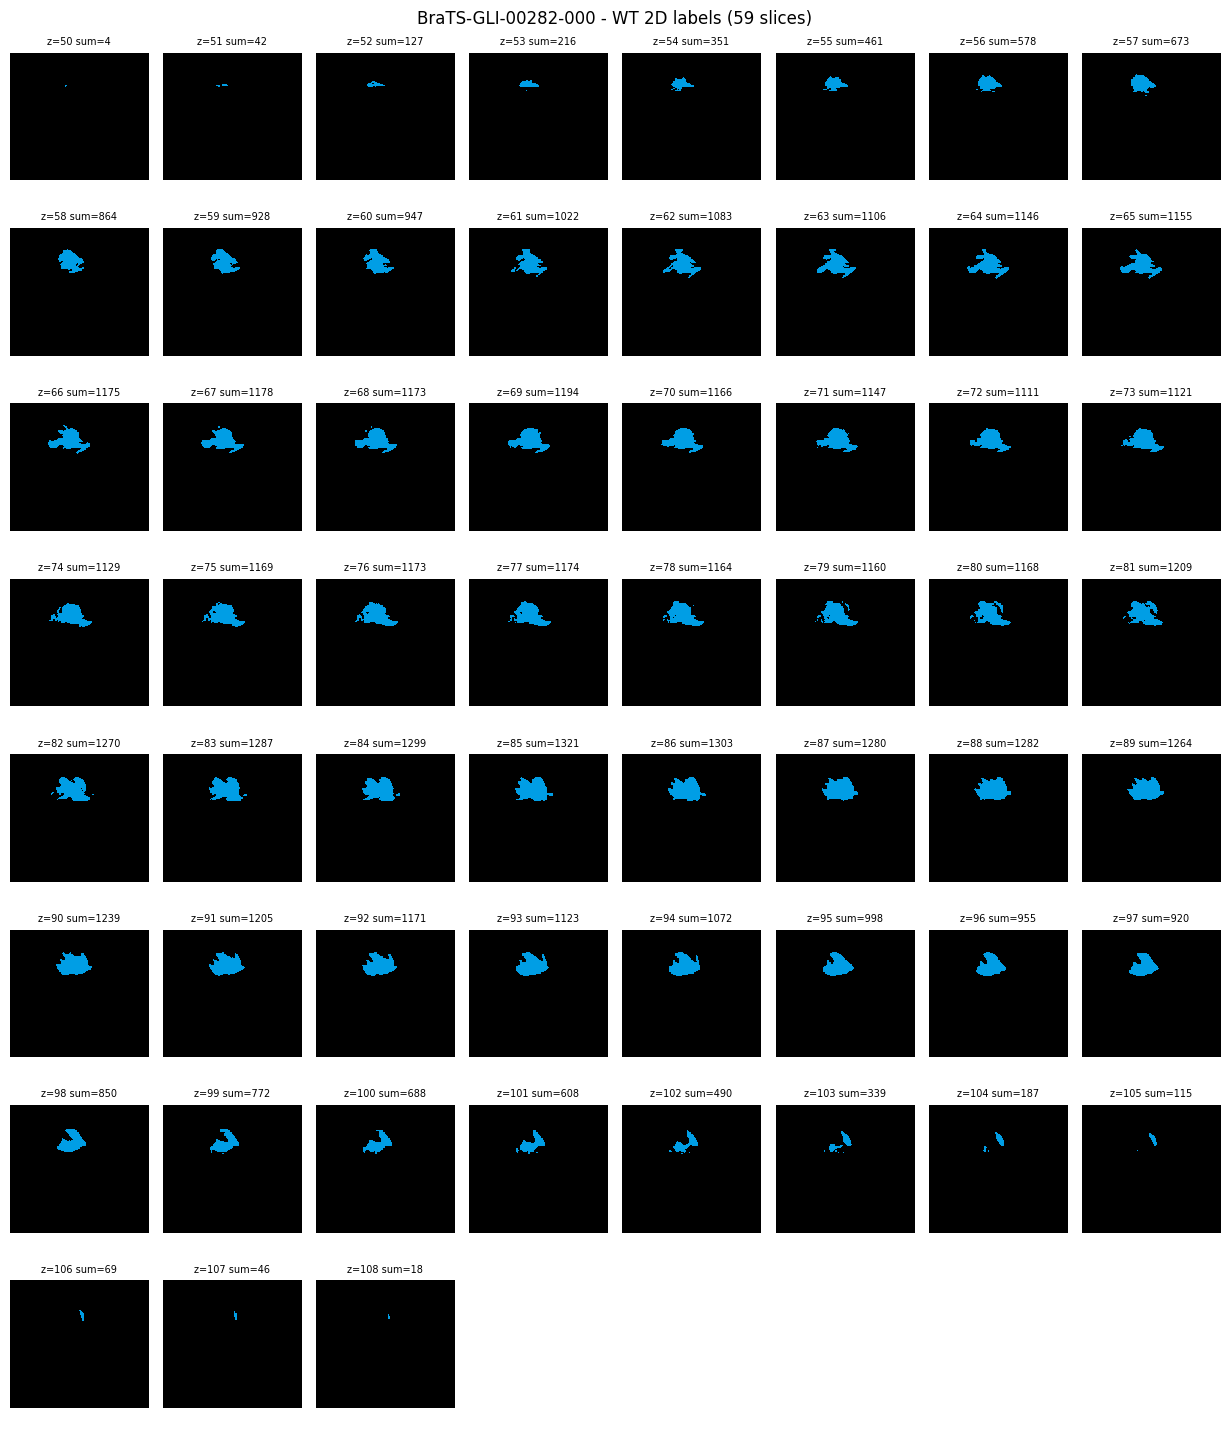

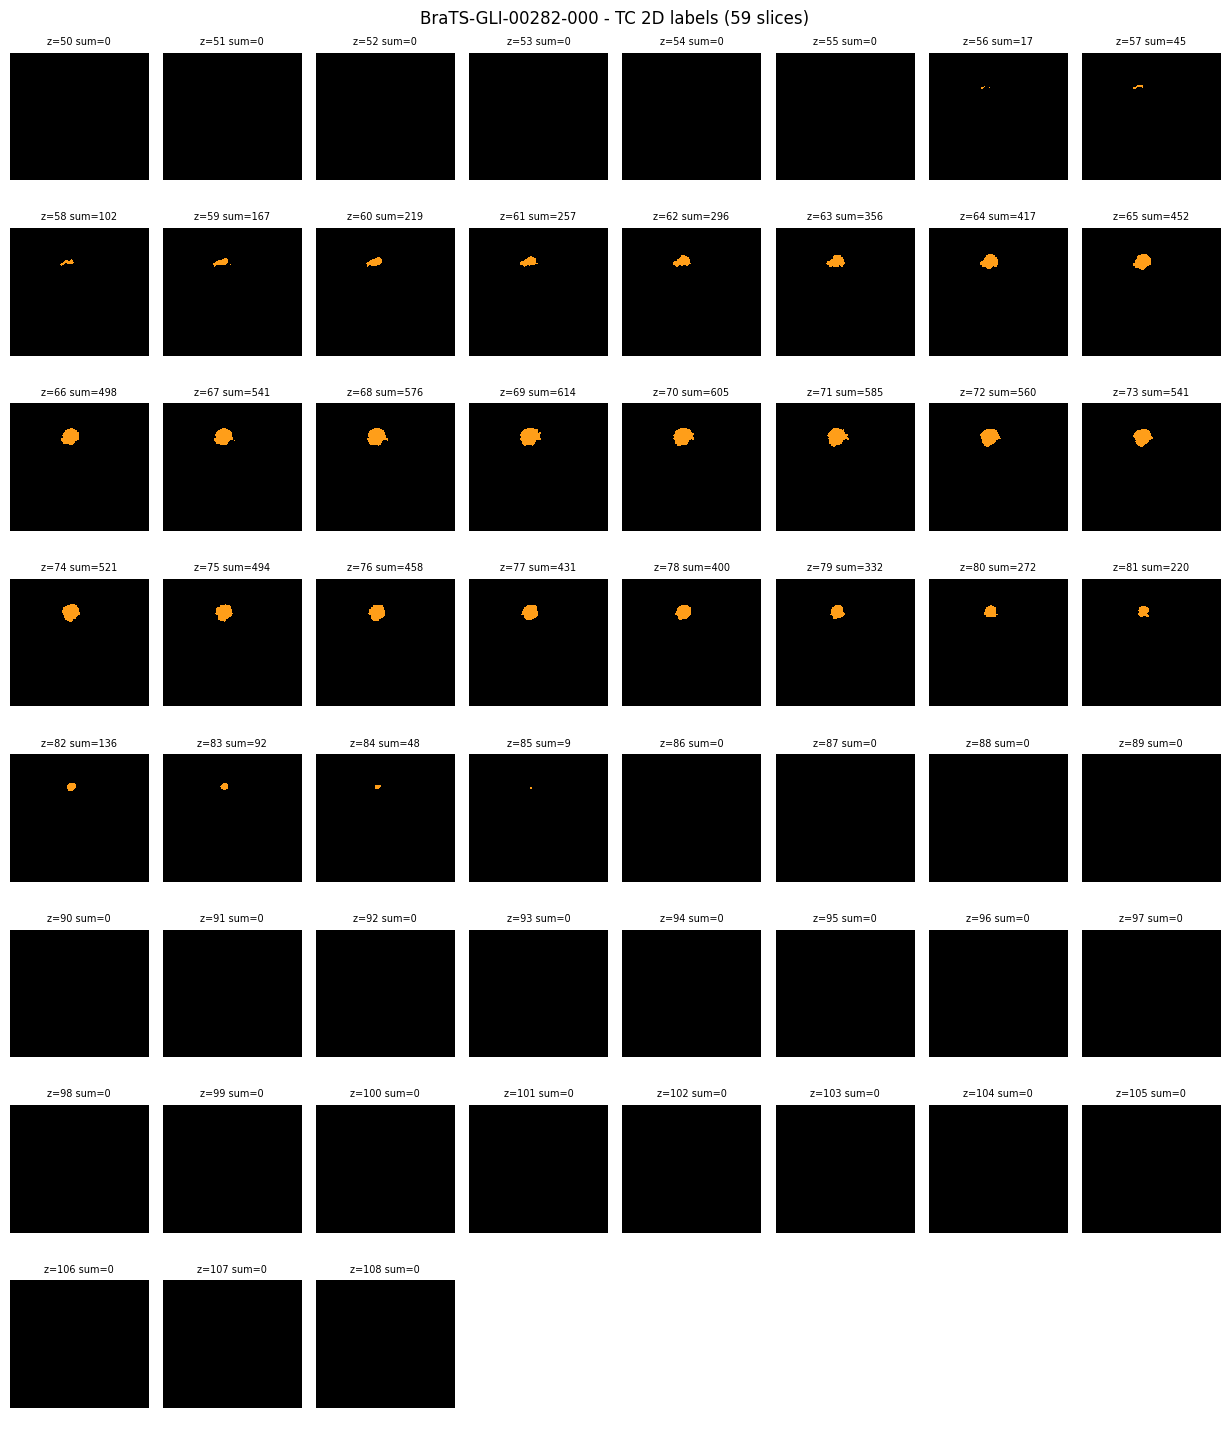

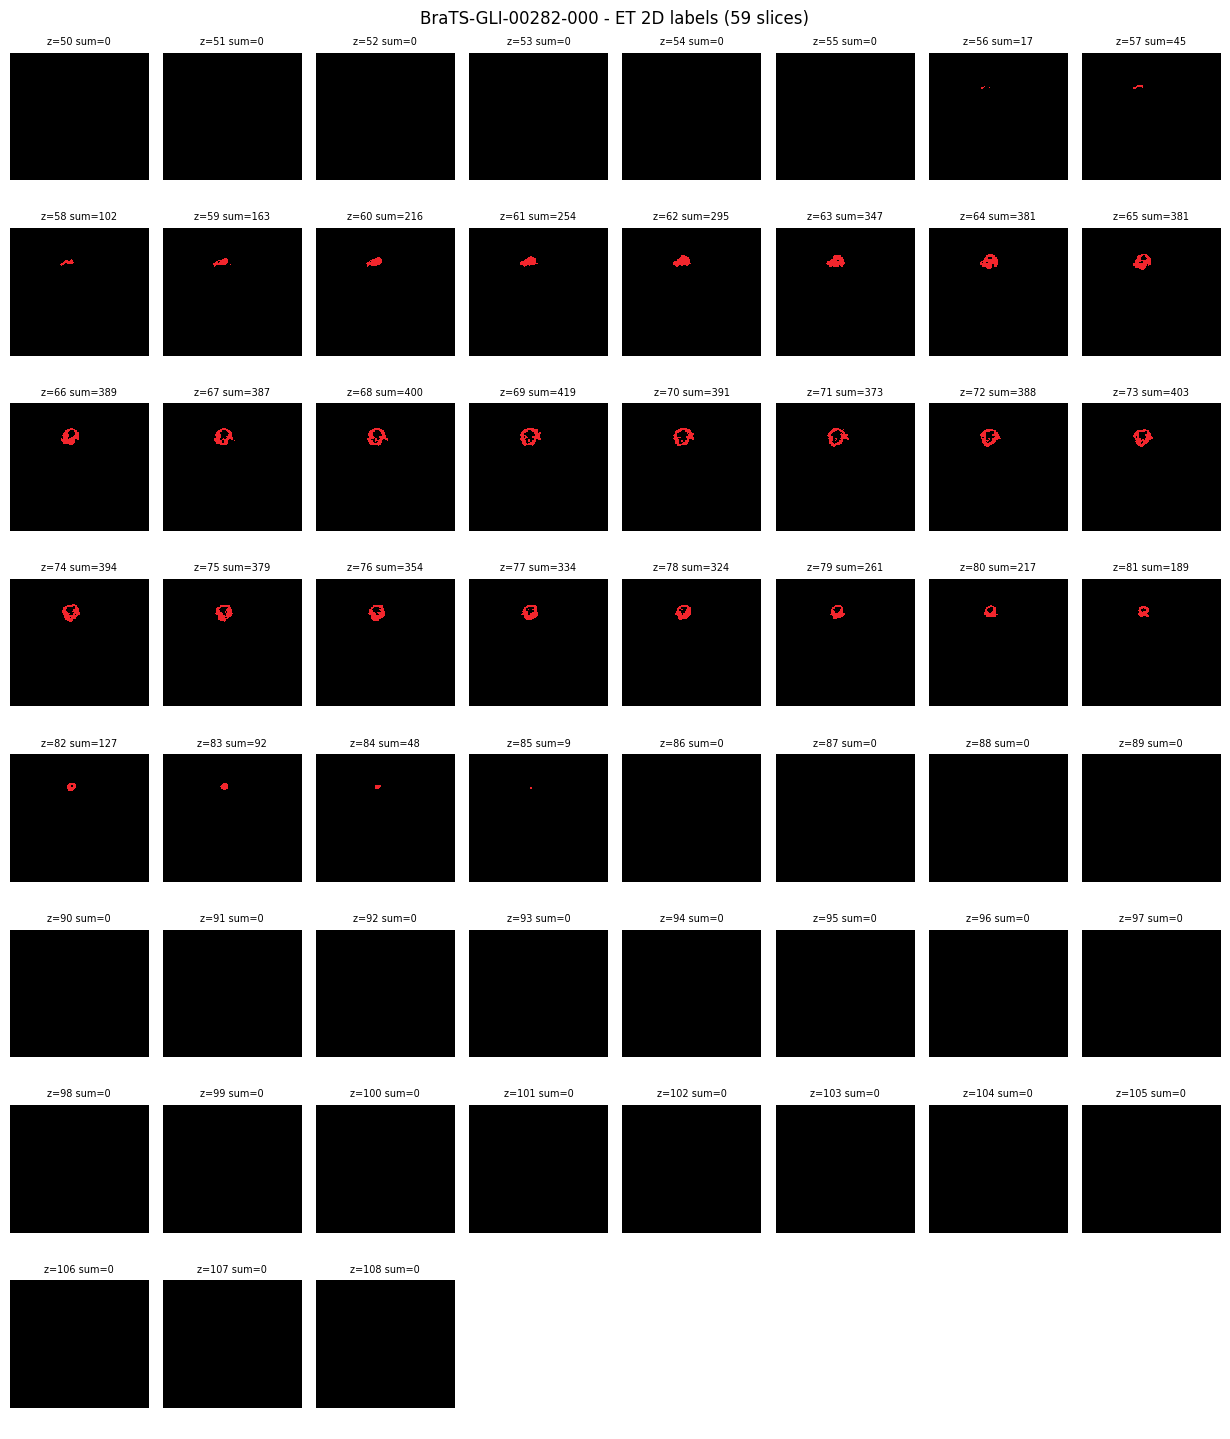

In [19]:
# Run this cell and enter a case id such as BraTS-GLI-00000-000.
# Numeric shortcuts also work when they are unambiguous, e.g. 0 -> BraTS-GLI-00000-000.
case_id = input("Enter 3D case id: ").strip()
case_data = show_case_labels(case_id, columns=8, skip_empty=False, mode="channels")

In [20]:
# Optional examples:
# show_case_labels("BraTS-GLI-00000-000", columns=8, mode="overlay")
# show_case_labels("BraTS-GLI-00000-000", columns=8, mode="both")